# A Visual Analysis of Heart Disease Prevalence

**Question:** Which clinical and symptom patterns are associated with heart disease, and do those patterns differ between men and women?

This notebook narrates the analysis. Every function it calls lives in `src/`; the whole pipeline can also be reproduced in one command:

```
python -m src.run_analysis
```

**Protocol in one paragraph.** The data is validated, de-duplicated, and copied to `data/clean/` (the raw file is never touched). The de-duplication matters: the raw 1,025-row file contains only 302 unique patients, and its 723 exact copies would otherwise leak across the split and inflate every metric (they briefly produced a fake accuracy of 1.000 in this project). The split happens *before* any modeling: 80% train / 20% held-out test, stratified so both halves keep the same disease ratio, seed fixed at 42. A Random Forest is trained on the training set only. Feature importance is computed three ways — built-in impurity importance, permutation importance on the held-out test set, and SHAP values for direction — and the model is evaluated on the test set (accuracy, confusion matrix, ROC-AUC). Finally, permutation importance is recomputed separately for male and female patients, with 500 bootstrap resamples per subgroup to attach a 95% interval to every number.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.config import FEATURES, SEED, TARGET
from src.data import build_clean
from src.split import stratified_split
from src.model import train_rf, evaluate
from src.importance import (
    builtin_importance,
    permutation_importance_table,
    shap_importance,
)
from src.gender import subgroup_sizes

print(f"Repo root: {ROOT}")
print(f"Seed: {SEED}")

Repo root: /tmp/opencode/heart-fix
Seed: 42


## 1. The data

Source: [Kaggle — Heart Disease Dataset](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset) (downloaded 2026-09-27, file `heart.csv`, SHA-256 `DDB2996B2F4DB2E00AAD13F4518200179FF69F79093838E3C21FFA672EBEC0F1`). The raw file lives untouched in `data/raw/`; `src.data.build_clean()` validates schema, value ranges, and missing values, then removes exact duplicate records and writes the analysis copy to `data/clean/`.

**Data-quality audit.** The raw file lists 1,025 rows but only **302 unique patients**: every patient was copied 3-4 times (one 8 times). Left in, a random 80/20 split would place 202 of 205 test rows as identical twins of training rows, and evaluation would reward memorization. Duplicates are dropped before anything else happens; the leakage regression test in `tests/` keeps it that way. One more quirk: for several variables (`ca`, `thal`, `exang`, `oldpeak`) the association with the target runs opposite to the classic UCI Cleveland cohort in this circulating file, so directions are reported in the file's own coding with no clinical-direction claims.

**Data dictionary** (confirmed against the actual file):

| Column | Meaning |
|---|---|
| `age` | Age in years (29–77) |
| `sex` | 0 = Female, 1 = Male |
| `cp` | Chest-pain type: 0 typical angina, 1 atypical angina, 2 non-anginal pain, 3 asymptomatic |
| `trestbps` | Resting blood pressure (mm Hg) |
| `chol` | Serum cholesterol (mg/dl) |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = yes) |
| `restecg` | Resting ECG: 0 normal, 1 ST-T abnormality, 2 LV hypertrophy |
| `thalach` | Maximum heart rate achieved |
| `exang` | Exercise-induced angina (1 = yes) |
| `oldpeak` | ST depression induced by exercise relative to rest |
| `slope` | Slope of the peak-exercise ST segment: 0 upsloping, 1 flat, 2 downsloping |
| `ca` | Major vessels colored by fluoroscopy (0–4) |
| `thal` | Thalassemia test: 0 unknown, 1 fixed defect, 2 normal, 3 reversible defect |
| `target` | Heart disease diagnosis: 0 = no disease, 1 = disease |

In [2]:
df = build_clean()
counts, target_rate = subgroup_sizes(df)

print(f"Rows: {len(df)}, columns: {df.shape[1]}")
print(f"Disease prevalence overall: {df[TARGET].mean():.3f}")
print(f"Patients per gender: {counts.to_dict()}")
print(f"Disease rate per gender: {target_rate.round(3).to_dict()}")
df.head()

Data-quality audit: 1025 raw rows, 723 exact duplicate records removed, 302 unique patients kept
Rows: 302, columns: 14
Disease prevalence overall: 0.543
Patients per gender: {'Male': 206, 'Female': 96}
Disease rate per gender: {'Female': 0.75, 'Male': 0.447}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 2. Split BEFORE anything else

241 patients for training, 61 held out for testing (80/20 of the 302 unique patients), stratified on the target, seed = 42. The test set is not touched again until evaluation — that is what turns "we found patterns" into "the patterns hold up on patients the model never saw".

In [3]:
X_train, X_test, y_train, y_test = stratified_split(df)
print(f"Train: {len(X_train)} rows, disease ratio {y_train.mean():.4f}")
print(f"Test:  {len(X_test)} rows, disease ratio {y_test.mean():.4f}")

Train: 241 rows, disease ratio 0.5436
Test:  61 rows, disease ratio 0.5410


## 3. Random Forest, trained on the training set only

500 trees, seed fixed. Evaluation happens on the 61 held-out patients, the trust gate for the importance rankings that follow.

Held-out test accuracy: 0.7869
Held-out ROC-AUC:       0.8653
Confusion matrix (rows = actual, cols = predicted):
[[22  6]
 [ 7 26]]


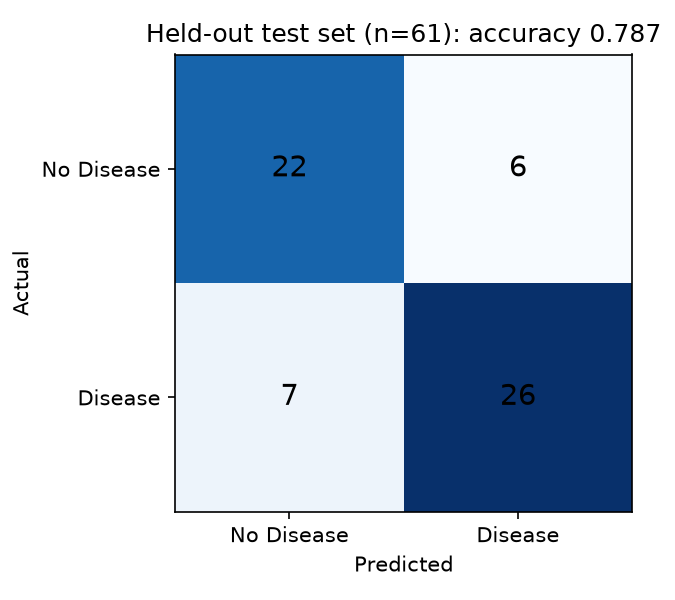

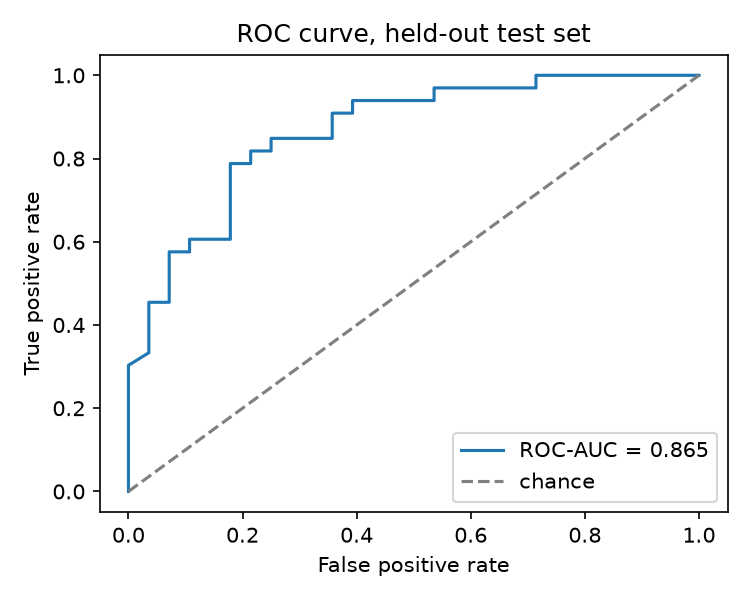

In [4]:
model = train_rf(X_train, y_train)
metrics = evaluate(model, X_test, y_test)

print(f"Held-out test accuracy: {metrics['accuracy']:.4f}")
print(f"Held-out ROC-AUC:       {metrics['roc_auc']:.4f}")
print(f"Confusion matrix (rows = actual, cols = predicted):")
print(metrics['confusion_matrix'])
display(Image(filename=str(ROOT / "figures" / "fig_confusion_matrix.png")))
display(Image(filename=str(ROOT / "figures" / "fig_roc_curve.png")))

## 4. Feature importance, three ways

- **Built-in impurity importance** comes free with the forest, but it is biased: it favors continuous features and splits credit between correlated ones. Shown for completeness, not trusted alone.
- **Permutation importance on the held-out test set** shuffles one feature at a time and measures how much accuracy drops. This is the honest ranking — it measures what the model actually relies on, on data it never saw during training. **This is the ranking the Tableau dashboard shows.**
- **SHAP values** answer the same "what matters" question but add *direction*: does a high value push risk up or down? Directions follow this file's own coding (see the caveat in section 1): for several variables the marginal association here runs opposite to the classic Cleveland cohort, so we report the pattern, not a clinical claim.

/tmp/opencode/heart-fix/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== Built-in impurity importance (biased, shown for reference) ===
 feature  importance
      cp    0.164836
 thalach    0.128033
      ca    0.109695
    thal    0.098495
 oldpeak    0.093274
     age    0.083300
    chol    0.075324
   exang    0.071491
trestbps    0.071248
     sex    0.038268
   slope    0.034041
 restecg    0.022457
     fbs    0.009538

=== Permutation importance on held-out test set (the honest ranking) ===
 feature  importance      std
      ca    0.064481 0.033041
    thal    0.038798 0.024124
     sex    0.028415 0.017925
 oldpeak    0.009836 0.016718
   exang    0.009836 0.016173
   slope    0.001639 0.012943
 thalach    0.000000 0.034126
     fbs    0.000000 0.000000
 restecg    0.000000 0.000000
trestbps   -0.002186 0.015686
    chol   -0.003825 0.015657
     age   -0.004918 0.014134
      cp   -0.015301 0.030796

=== SHAP: importance + direction ===
 feature  mean_abs_shap          direction
      cp       0.119741 higher raises risk
      ca       0.0892

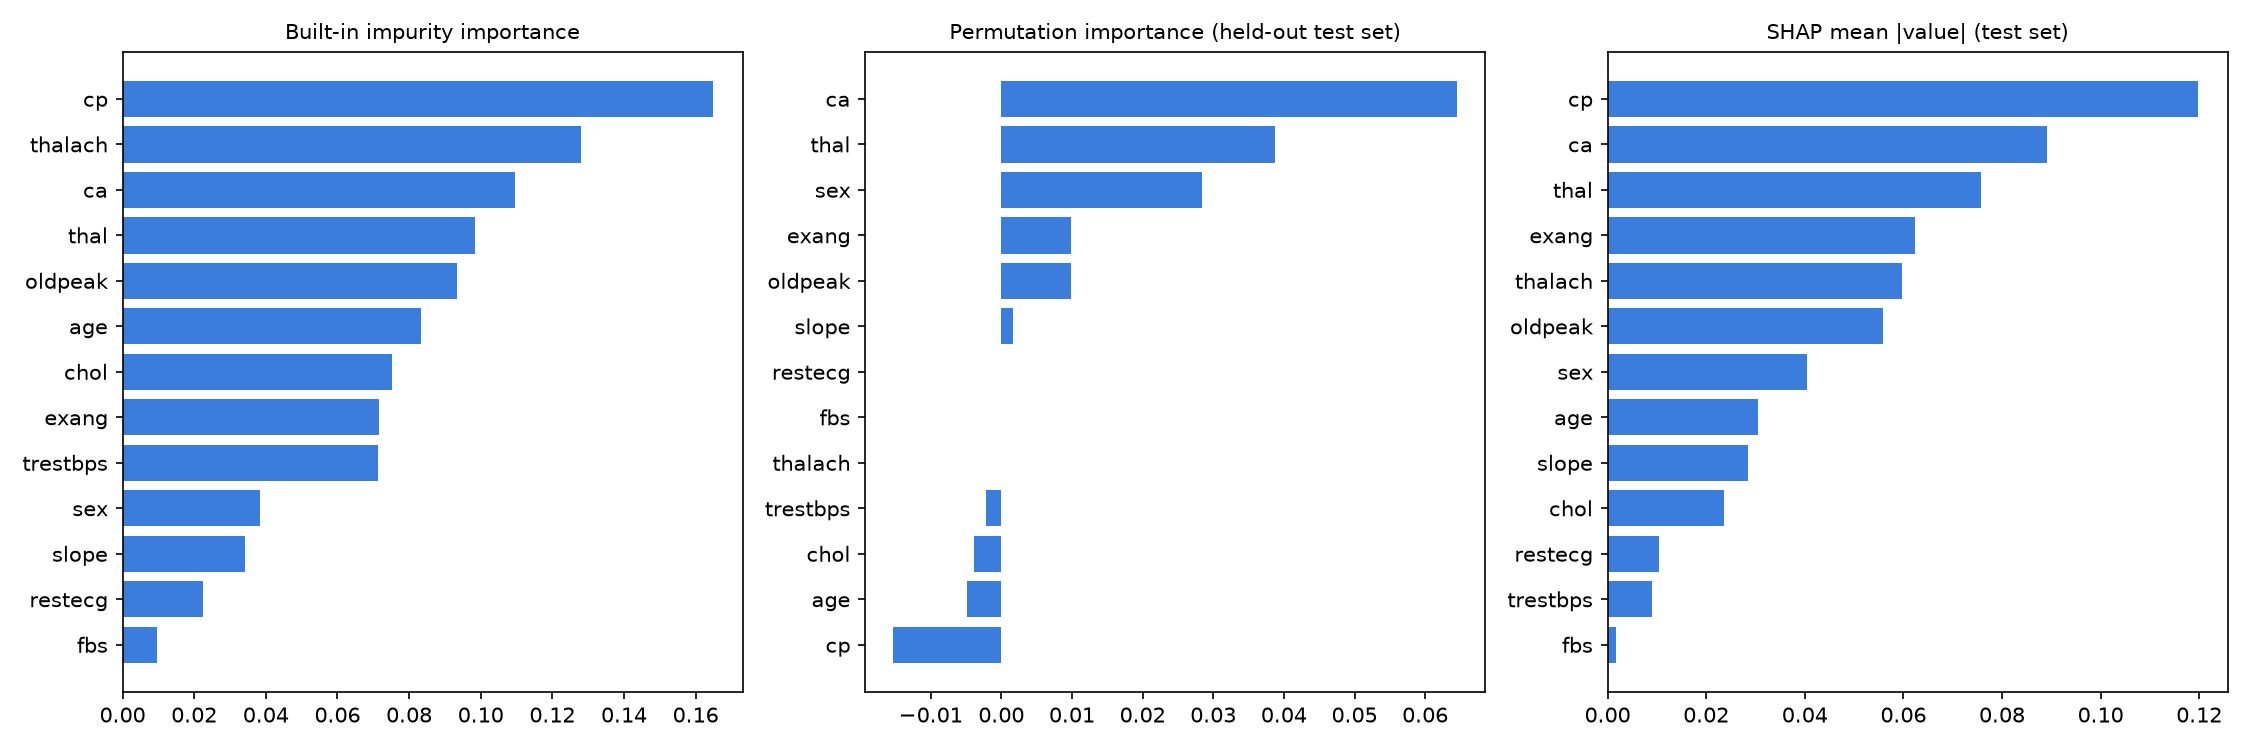

In [5]:
builtin = builtin_importance(model)
permutation = permutation_importance_table(model, X_test, y_test)
shap_table = shap_importance(model, X_test)

print("=== Built-in impurity importance (biased, shown for reference) ===")
print(builtin.to_string(index=False))
print("\n=== Permutation importance on held-out test set (the honest ranking) ===")
print(permutation.to_string(index=False))
print("\n=== SHAP: importance + direction ===")
print(shap_table.to_string(index=False))
display(Image(filename=str(ROOT / "figures" / "fig_importance_methods.png")))

## 5. Does importance shift by gender?

The headline question. A Random Forest is refit within each gender subgroup (train rows only), permutation importance is measured on that subgroup's held-out test rows, and the whole procedure is repeated over **500 bootstrap resamples** per subgroup to attach a 95% interval to every feature's importance.

The cell below loads the table produced by `python -m src.run_analysis` (the bootstrap takes a few minutes; rerunning it here would only slow the notebook down — the function is `src.gender.full_gender_analysis`).

**Language discipline.** If a feature ranks high for one gender and low for the other with *non-overlapping* intervals, the difference is supported. If intervals overlap, the honest verdict is "suggestive, not conclusive at this sample size".

          male_importance  female_importance  male_rank  female_rank
feature                                                             
ca                 0.0612            -0.0463          1           13
oldpeak            0.0411            -0.0389          2           11
chol               0.0349             0.0000          3            7
exang              0.0233             0.0352          4            1
age                0.0217             0.0019          5            4
thalach            0.0147             0.0000          6            7
slope              0.0078             0.0037          7            3
thal               0.0078             0.0148          7            2
sex                0.0000             0.0000         10            7
fbs                0.0000             0.0000         10            7
restecg            0.0000             0.0000         10            7
cp                -0.0031            -0.0444         12           12
trestbps          -0.0070         

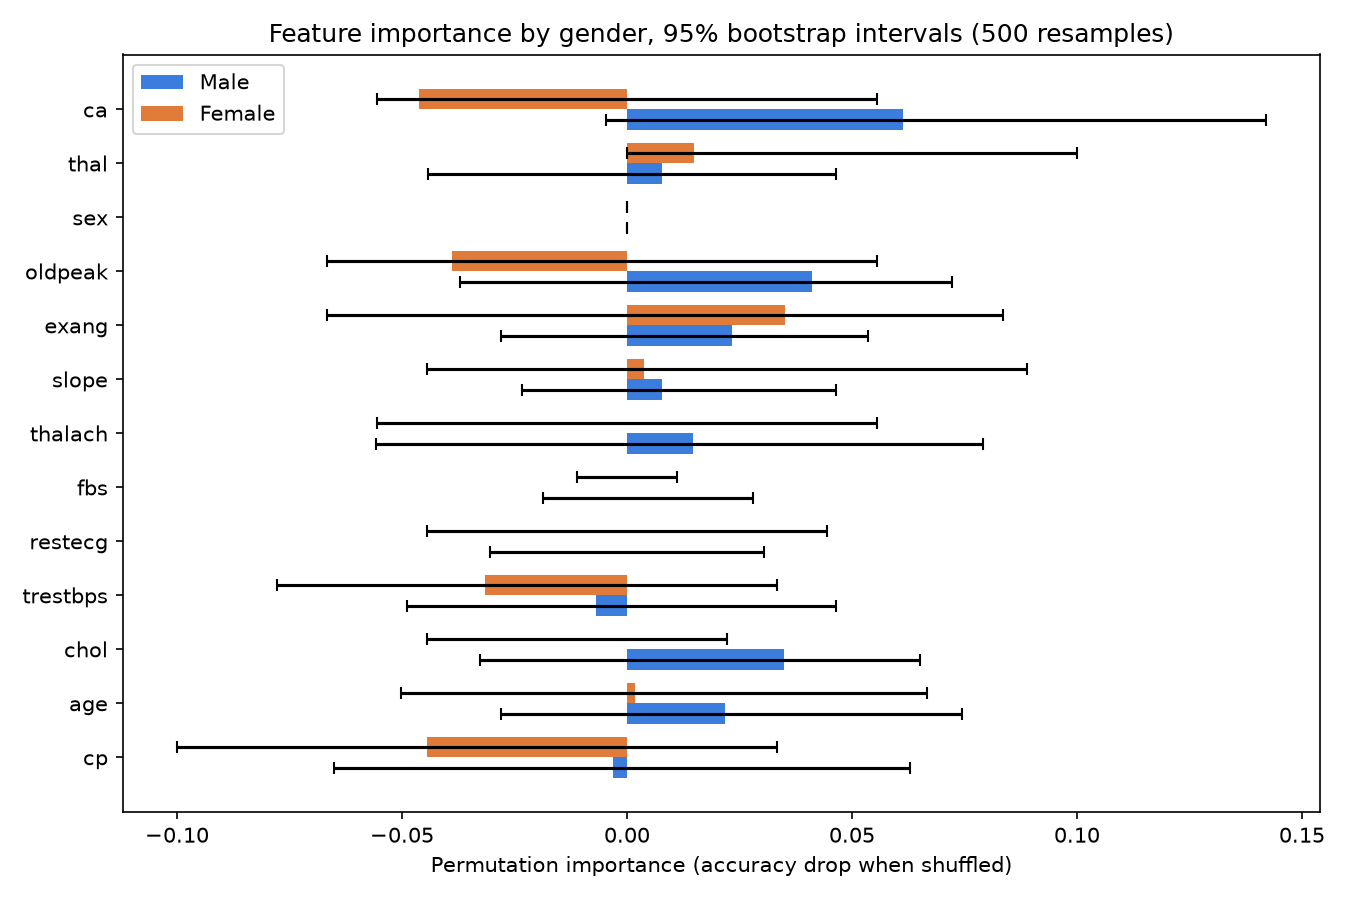

In [6]:
gender_ci = pd.read_csv(ROOT / "data" / "processed" / "gender_importance_ci.csv")

male = gender_ci[gender_ci["group"] == "Male"].set_index("feature")
female = gender_ci[gender_ci["group"] == "Female"].set_index("feature")
compare = male[["importance"]].rename(columns={"importance": "male_importance"}).join(
    female[["importance"]].rename(columns={"importance": "female_importance"})
)
compare["male_rank"] = compare["male_importance"].rank(ascending=False).astype(int)
compare["female_rank"] = compare["female_importance"].rank(ascending=False).astype(int)
print(compare.sort_values("male_importance", ascending=False).round(4).to_string())
print()
print(gender_ci.round(4).to_string(index=False))
display(Image(filename=str(ROOT / "figures" / "fig_gender_importance.png")))

**What the intervals say (seed 42, 500 resamples):**

- For **men**, the ranking leans on `ca` (vessels colored; importance 0.061, 95% CI [-0.005, 0.142]) and `oldpeak` (0.041, CI [-0.037, 0.072]). For **women**, `exang` (0.035, CI [-0.067, 0.084]) and `thal` (0.015, CI [0.000, 0.100]) lead. The rankings differ descriptively.
- But every interval overlaps, so **no gender difference is statistically supported at this sample size** (the female test subgroup is only 18 patients). Before the duplicate cleanup, the `ca` gap looked supported with non-overlapping intervals; removing the leak erased it. The descriptive pattern is a hypothesis for a larger cohort, not a finding.
- `sex` ranks 3rd in the overall held-out ranking here, so it carries real standalone signal in this dataset on top of its role in *modifying* which features matter.

## 6. What feeds the Tableau dashboard

`python -m src.run_analysis` writes two Tableau-ready exports to `data/processed/tableau/`:

- `tableau_feature_importance.csv`: the permutation importances above, long format (Overall / Male / Female, with 95% intervals for the gender groups). Powers the side-by-side gender view.
- `tableau_patients_labeled.csv`: all 302 unique patients with human-readable labels plus an age-group column. Powers the prevalence heatmap and grouped-bar views.

Dashboard filters (exact list): **gender, age group, chest-pain type**. See `tableau/build_spec.md` for the sheet-by-sheet build instructions.

## Summary

1. **Audit first.** The raw file's 1,025 rows contain 723 exact duplicate patient records (302 unique patients). Removed before splitting; without that step the held-out evaluation reads a fake 1.000 by memorization, and a gender gap appears that the clean data does not support.
2. A Random Forest trained on 241 unique patients reaches **accuracy 0.787 and ROC-AUC 0.865** on 61 held-out patients: *predicts*, because it was measured on patients the model never saw, and the honest band for this cohort.
3. The held-out ranking leans on `ca`, `thal`, and `sex`; `cp` dominates impurity importance and SHAP but does not survive held-out permutation, because the forest routes the same information through correlated features.
4. The ranking **shifts descriptively by gender** (men: `ca`, `oldpeak`; women: `exang`, `thal`), but all intervals overlap at n = 302, so every shift is reported as *suggestive, not conclusive*: a hypothesis for a larger cohort.

*Team: Vrunda Joshi (team lead), Meet Gandhi, Kashyap Patel, Masum Udecha. DS612 Interactive Data Visualization, Autumn 2026, Dhirubhai Ambani University. Presented in class with the course instructor as project jury.*